The importance of a  recursive forecast consists on the model using its own predictions to predict further more into the future

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Load data
df = pd.read_csv("/Users/jussaragaspar/Downloads/Final project/time_series_60min_singleindex_filtered.csv")

# Convert timestamp
df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"])
df = df.set_index("utc_timestamp")

# Keep only FRANCE demand first
df_model = df[["FR_load_actual_entsoe_transparency"]].dropna().copy()

# Create lagged features
df_model["lag_1"] = df_model["FR_load_actual_entsoe_transparency"].shift(1)
df_model["lag_24"] = df_model["FR_load_actual_entsoe_transparency"].shift(24)
df_model["lag_168"] = df_model["FR_load_actual_entsoe_transparency"].shift(168)

# Time features
df_model["hour"] = df_model.index.hour
df_model["dayofweek"] = df_model.index.dayofweek

df_model = df_model.dropna()

X = df_model[["lag_1", "lag_24", "lag_168", "hour", "dayofweek"]]
y = df_model["FR_load_actual_entsoe_transparency"]

In [78]:
X = df_model[["lag_1", "lag_24", "lag_168", "hour", "dayofweek"]]
y = df_model["FR_load_actual_entsoe_transparency"]

In [79]:
# Train-test split
X_train, X_test = X.iloc[:int(len(X) * 0.8)], X.iloc[int(len(X) * 0.8):]
y_train, y_test = y.iloc[:int(len(y) * 0.8)], y.iloc[int(len(y) * 0.8):]

In [80]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

                                 cet_cest_timestamp  \
utc_timestamp                                         
2014-12-31 23:00:00+00:00  2015-01-01T00:00:00+0100   
2015-01-01 00:00:00+00:00  2015-01-01T01:00:00+0100   
2015-01-01 01:00:00+00:00  2015-01-01T02:00:00+0100   
2015-01-01 02:00:00+00:00  2015-01-01T03:00:00+0100   
2015-01-01 03:00:00+00:00  2015-01-01T04:00:00+0100   

                           BE_load_actual_entsoe_transparency  \
utc_timestamp                                                   
2014-12-31 23:00:00+00:00                                 NaN   
2015-01-01 00:00:00+00:00                              9484.0   
2015-01-01 01:00:00+00:00                              9152.0   
2015-01-01 02:00:00+00:00                              8799.0   
2015-01-01 03:00:00+00:00                              8567.0   

                           BE_load_forecast_entsoe_transparency  \
utc_timestamp                                                     
2014-12-31 23:00:00+00:0

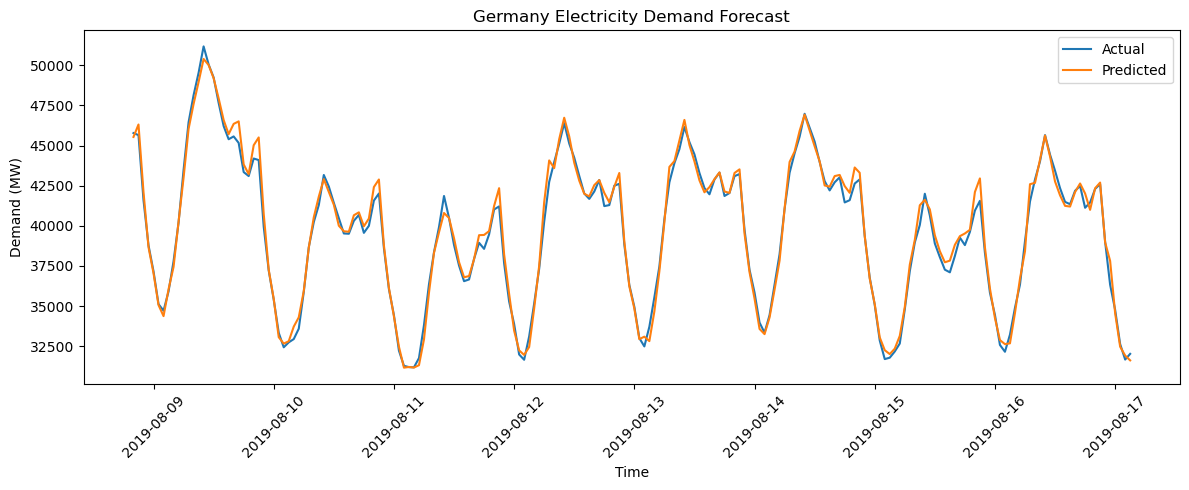

                           total_demand  total_generation  grid_balance
utc_timestamp                                                          
2014-12-31 23:00:00+00:00           NaN               NaN           NaN
2015-01-01 00:00:00+00:00           NaN               NaN           NaN
2015-01-01 01:00:00+00:00      119060.0               NaN           NaN
2015-01-01 02:00:00+00:00      114322.0               NaN           NaN
2015-01-01 03:00:00+00:00      111514.0               NaN           NaN


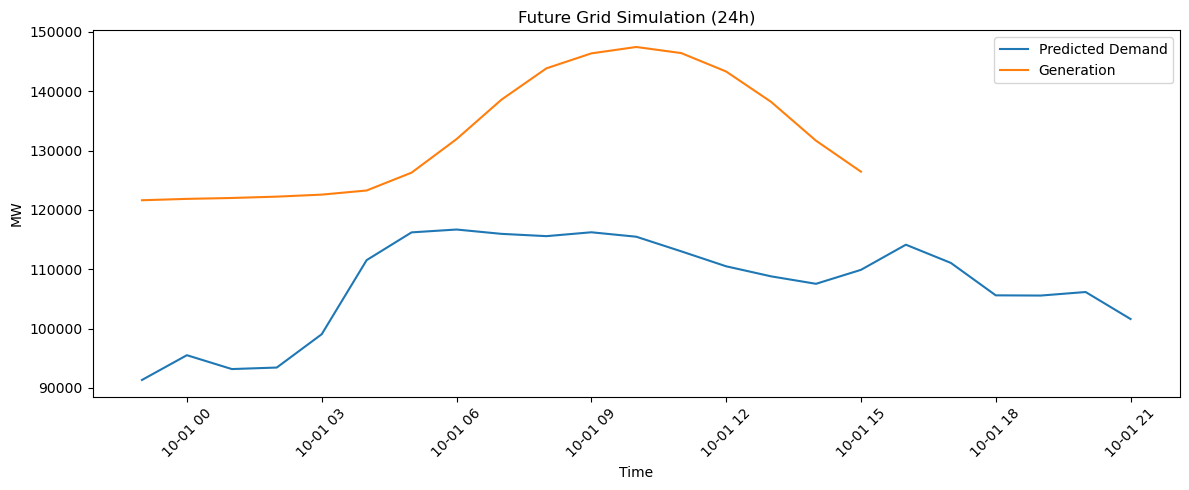

          Scenario  Shortage Rate (%)  Average Grid Balance (MW)
0             Base           0.000000               24959.072647
1      Demand +10%           4.166667               14194.738324
2  Generation -15%          16.666667                5068.710265
3  Generation +10%           0.000000               38219.314235


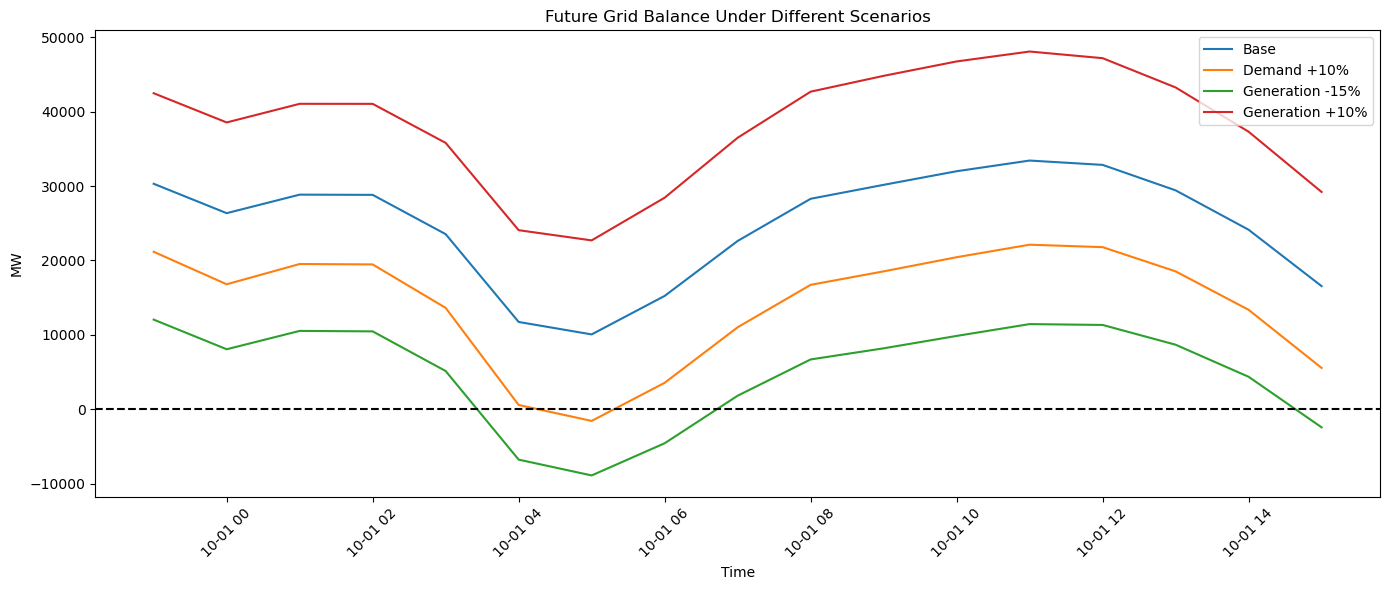

lag_1        0.959692
hour         0.015989
lag_24       0.011309
lag_168      0.010335
dayofweek    0.002675
dtype: float64


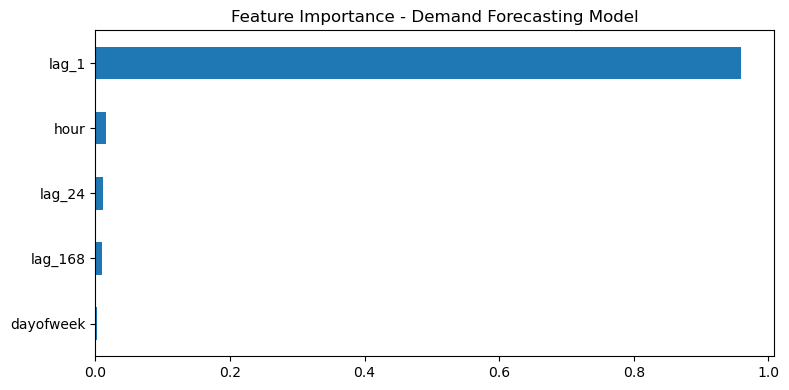

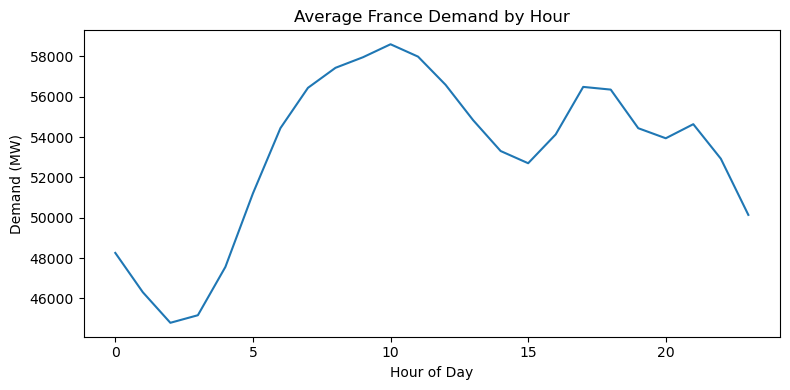

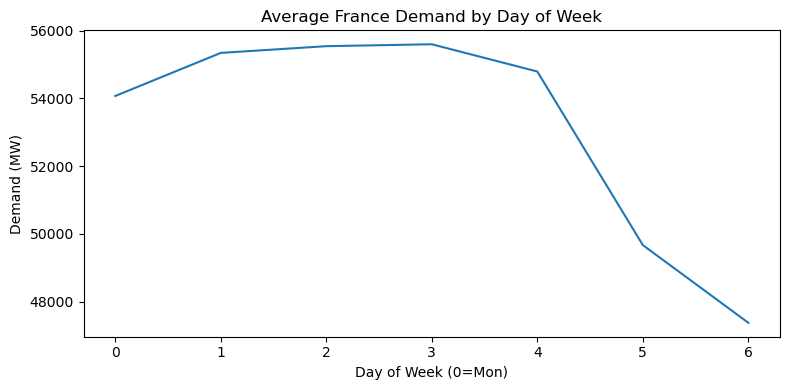

In [ ]:
# 1. IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error


# 2. LOAD DATA

df = pd.read_csv("/Users/jussaragaspar/Downloads/Final project/time_series_60min_singleindex_filtered.csv")

# Convert timestamp and set as index
df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"])
df = df.set_index("utc_timestamp")

print(df.head())
print(df.columns)


# 3. KEEP ONLY THE COLUMNS NEEDED

cols = [
    "DE_load_actual",
    "FR_load_actual",
    "BE_load_actual",
    "DE_wind_generation_actual",
    "DE_solar_generation_actual",
    "FR_solar_generation_actual",
    "BE_solar_generation_actual"
]


# 4. FORECASTING DATASET FOR GERMANY DEMAND

df_model = df[["FR_load_actual_entsoe_transparency"]].copy()

# Lag features
df_model["lag_1"] = df_model["FR_load_actual_entsoe_transparency"].shift(1)
df_model["lag_24"] = df_model["FR_load_actual_entsoe_transparency"].shift(24)
df_model["lag_168"] = df_model["FR_load_actual_entsoe_transparency"].shift(168)

# Time features
df_model["hour"] = df_model.index.hour
df_model["dayofweek"] = df_model.index.dayofweek

df_model = df_model.dropna()

print(df_model.head())


# 5. DEFINE X AND y

X = df_model[["lag_1", "lag_24", "lag_168", "hour", "dayofweek"]]
y = df_model["FR_load_actual_entsoe_transparency"]



# 6. TRAIN / TEST SPLIT

split = int(len(df_model) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]



# 7. TRAIN FORECASTING MODEL

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


# 8. EVALUATE MODEL

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
print("MAE:", mae)



# 9. PLOT ACTUAL VS PREDICTED

plt.figure(figsize=(12, 5))
plt.plot(y_test.index[:200], y_test.iloc[:200], label="Actual")
plt.plot(y_test.index[:200], pred[:200], label="Predicted")
plt.legend()
plt.title("Germany Electricity Demand Forecast")
plt.ylabel("Demand (MW)")
plt.xlabel("Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 10. BUILD HISTORICAL GRID VARIABLES

df_grid = df.copy()

df_grid["total_demand"] = (
    df_grid["DE_load_actual_entsoe_transparency"] +
    df_grid["FR_load_actual_entsoe_transparency"] +
    df_grid["BE_load_actual_entsoe_transparency"]
)

df_grid["renewable_generation"] = (
    df_grid["DE_wind_generation_actual"] +
    df_grid["DE_solar_generation_actual"] +
    df_grid["FR_solar_generation_actual"] +
    df_grid["BE_solar_generation_actual"]
)

# Base generation to make the system realistic
df_grid["other_generation"] = 120000

df_grid["total_generation"] = (
    df_grid["renewable_generation"] + df_grid["other_generation"]
)

df_grid["grid_balance"] = df_grid["total_generation"] - df_grid["total_demand"]

print(df_grid[["total_demand", "total_generation", "grid_balance"]].head())


# 11. RECURSIVE FORECAST - NEXT 24 HOURS

history = df_model.copy()
future_preds = []

for i in range(24):
    lag_1 = history["FR_load_actual_entsoe_transparency"].iloc[-1]
    lag_24 = history["FR_load_actual_entsoe_transparency"].iloc[-24]
    lag_168 = history["FR_load_actual_entsoe_transparency"].iloc[-168]

    next_time = history.index[-1] + pd.Timedelta(hours=1)
    hour = next_time.hour
    dayofweek = next_time.dayofweek

    X_future = pd.DataFrame({
        "lag_1": [lag_1],
        "lag_24": [lag_24],
        "lag_168": [lag_168],
        "hour": [hour],
        "dayofweek": [dayofweek]
    })

    next_pred = model.predict(X_future)[0]
    future_preds.append(next_pred)

    new_row = pd.DataFrame(
        {"DE_load_actual_entsoe_transparency": [next_pred]},
        index=[next_time]
    )

    history = pd.concat([history, new_row])


# 12. BUILD FUTURE DATAFRAME

future_index = pd.date_range(
    start=df_model.index[-1] + pd.Timedelta(hours=1),
    periods=24,
    freq="h"
)

df_future = pd.DataFrame(index=future_index)
df_future["DE_predicted_demand"] = future_preds



# 13. ADD FRANCE AND BELGIUM DEMAND BASELINES

df_future["FR_demand"] = df["FR_load_actual_entsoe_transparency"].iloc[-24:].values
df_future["BE_demand"] = df["BE_load_actual_entsoe_transparency"].iloc[-24:].values

df_future["total_demand"] = (
    df_future["DE_predicted_demand"] +
    df_future["FR_demand"] +
    df_future["BE_demand"]
)


# 14. ADD FUTURE GENERATION BASELINE

df_future["renewable_generation"] = df_grid["renewable_generation"].iloc[-24:].values
df_future["other_generation"] = 120000
df_future["total_generation"] = (
    df_future["renewable_generation"] + df_future["other_generation"]
)

df_future["grid_balance"] = df_future["total_generation"] - df_future["total_demand"]

# 15. PLOT FUTURE DEMAND VS GENERATION

plt.figure(figsize=(12, 5))
plt.plot(df_future.index, df_future["total_demand"], label="Predicted Demand")
plt.plot(df_future.index, df_future["total_generation"], label="Generation")
plt.legend()
plt.title("Future Grid Simulation (24h)")
plt.ylabel("MW")
plt.xlabel("Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 16. SCENARIO 1 - DEMAND SURGE (+10%)

df_future_s1 = df_future.copy()
df_future_s1["total_demand"] = df_future_s1["total_demand"] * 1.10
df_future_s1["grid_balance"] = df_future_s1["total_generation"] - df_future_s1["total_demand"]


# 17. SCENARIO 2 - GENERATION DROP (-15%)

df_future_s2 = df_future.copy()
df_future_s2["total_generation"] = df_future_s2["total_generation"] * 0.85
df_future_s2["grid_balance"] = df_future_s2["total_generation"] - df_future_s2["total_demand"]


# 18. SCENARIO 3 - GENERATION INCREASE (+10%)

df_future_s3 = df_future.copy()
df_future_s3["total_generation"] = df_future_s3["total_generation"] * 1.10
df_future_s3["grid_balance"] = df_future_s3["total_generation"] - df_future_s3["total_demand"]



# 19. COMPARE SCENARIOS

def shortage_rate(df_in):
    return (df_in["grid_balance"] < 0).mean() * 100

def avg_balance(df_in):
    return df_in["grid_balance"].mean()

scenario_results = pd.DataFrame({
    "Scenario": ["Base", "Demand +10%", "Generation -15%", "Generation +10%"],
    "Shortage Rate (%)": [
        shortage_rate(df_future),
        shortage_rate(df_future_s1),
        shortage_rate(df_future_s2),
        shortage_rate(df_future_s3)
    ],
    "Average Grid Balance (MW)": [
        avg_balance(df_future),
        avg_balance(df_future_s1),
        avg_balance(df_future_s2),
        avg_balance(df_future_s3)
    ]
})

print(scenario_results)



# 20. PLOT SCENARIO BALANCES

plt.figure(figsize=(14, 6))

plt.plot(df_future.index, df_future["grid_balance"], label="Base")
plt.plot(df_future_s1.index, df_future_s1["grid_balance"], label="Demand +10%")
plt.plot(df_future_s2.index, df_future_s2["grid_balance"], label="Generation -15%")
plt.plot(df_future_s3.index, df_future_s3["grid_balance"], label="Generation +10%")

plt.axhline(0, color="black", linestyle="--")
plt.title("Future Grid Balance Under Different Scenarios")
plt.ylabel("MW")
plt.xlabel("Time")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# 21. FEATURE IMPORTANCE

importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

plt.figure(figsize=(8, 4))
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance - Demand Forecasting Model")
plt.tight_layout()
plt.show()


# 22. DAILY PATTERN INSIGHT

plt.figure(figsize=(8, 4))
df_model.groupby(df_model.index.hour)["FR_load_actual_entsoe_transparency"].mean().plot()
plt.title("Average France Demand by Hour")
plt.ylabel("Demand (MW)")
plt.xlabel("Hour of Day")
plt.tight_layout()
plt.show()



# 23. WEEKLY PATTERN INSIGHT

plt.figure(figsize=(8, 4))
df_model.groupby(df_model.index.dayofweek)["FR_load_actual_entsoe_transparency"].mean().plot()
plt.title("Average France Demand by Day of Week")
plt.ylabel("Demand (MW)")
plt.xlabel("Day of Week (0=Mon)")
plt.tight_layout()
plt.show()






# ⚡ Forecasting Model and Recursive Logic — Full Explanation

The objective of this model is to **predict future electricity demand and simulate how the power grid will behave**. This is a key component of the digital twin, because it allows us to move from analyzing past data to **simulating future conditions**.

The process starts with preparing the data so that the model can learn how electricity demand behaves over time. . These include lag variables such as the demand one hour ago (`lag_1`), the demand at the same hour the previous day (`lag_24`), and the demand at the same hour the previous week (`lag_168`). I've also includd time-related features such as the hour of the day and the day of the week. These features are essential because electricity demand follows strong daily and weekly patterns, and the model needs this information to learn those patterns.

Once the data is prepared, the model is trained using historical data. During training, the model learns the relationship between past demand and future demand. For example, it learns that demand is usually higher in the morning and evening, lower at night, and different on weekends compared to weekdays.

After training, the model can be used to make predictions. First, it predicts the demand for the next hour. However, predicting only one step ahead is not sufficient for a digital twin. We need to simulate multiple future time steps, such as the next 24 hours. To achieve this, I used a method called **recursive forecasting**.

Recursive forecasting works by predicting one step at a time and then using that prediction to generate the next one. In each iteration of the loop, the model takes the most recent data available, including previous predictions, and predicts the next hour. The process follows several steps: first, the model retrieves the most recent demand values (such as the last hour, the previous day, and the previous week). Then, it advances the time by one hour and extracts the corresponding time features (hour and day of the week). These inputs are used to build a new input vector, which is passed to the model to generate a prediction. This prediction is then stored and added to the dataset, effectively becoming part of the “history” used for the next prediction.

This process is repeated multiple times (for example, 24 times) to simulate the next 24 hours. As a result, the model generates a full sequence of future demand values. This approach is necessary because real future data is unknown, so the model must rely on its own predictions to build the future step by step.

Once the future demand is predicted, it is combined with the demand from other countries to represent the total system demand. At the same time, electricity generation is estimated using available data such as renewable generation (wind and solar) and a base generation component that represents other energy sources like nuclear or gas. The difference between total generation and total demand is then calculated to obtain the **grid balance**, which indicates whether the system has enough electricity.

The grid balance is the core indicator of the system. If it is positive, there is enough electricity; if it is negative, there is a shortage. This allows us to evaluate the stability of the system over time.

Finally, this forecasting framework enables the creation of scenarios. By modifying demand or generation (for example, increasing demand or reducing wind production), we can simulate different situations and observe how the grid reacts. This is what makes the model a true digital twin: it not only predicts the future but also allows us to test how the system behaves under different conditions.

One limitation of this approach is that errors can accumulate over time, because each prediction is used as input for the next one. However, this is a known characteristic of recursive forecasting and is acceptable for short-term simulations.

In short, the forecasting model uses past data to learn patterns, predicts future demand step by step using a recursive approach, and enables the simulation of the power grid under different scenarios. This transforms the project from simple data analysis into a dynamic system capable of evaluating future performance and stability.
